# 22a — Series 22 opener: **z-scored reward** (a per-step adaptive-LR diagnostic) + distribution dynamics

**Series 22 = deeper understanding of the distributions the model generates.** This first notebook
builds the interactive view that the rest of the series will use, and uses it to run one clean test.

**One change vs 21i:** the μ REINFORCE reward goes from the RAW per-run log-likelihood
(`loglik_sum`, 21i) to the **z-scored** one (`loglik_z`). Everything else is 21i verbatim:
Anuar's per-run Gaussian log-likelihood of the real data, score denominator = the experiment's own
`sigma_prop`, **no gradient clip** (`CLIP=inf`), **no parameter clamps**, only the divergence STOP,
N_RUNS=100, N_ITER=30, init at `0.5 x truth`.

**Why z-scoring.** The REINFORCE μ step is `grad_mu = -(r - mean r)·score`. Replacing `r` by
`(r - mean r)/std(r)` leaves the (already centred) direction untouched and multiplies the gradient by
exactly `1/std(r)` — a **single scalar per step**. So `loglik_z` is, mathematically, an
**adaptive learning rate `LR_MU/std(r)`** instead of a fixed `LR_MU`. The question this notebook asks:
does that per-step normalisation help the residual μ overshoot at mid-T, where 21i's single fixed LR
was too large for the low-gradient cells? (It cannot fix the γ low-T blow-up — 21k showed that is a
property of the *state*, not the schedule — nor the μ information limit.)

**LR calibration (required).** Because z-scoring rescales the step, `LR_MU=1e-4` is no longer the
matching value. So `LR_MU_Z` is **re-matched** so that the z-arm's *median* step equals 21i's
(`TARGET_STEP = 3.3` photons/iter = `1e-4 x 3.3e4`). This keeps the per-step adaptivity as the *only*
behavioural change vs 21i. See the calibration cell.

**Prediction (falsifiable).** If the mid-T μ overshoot is reward-scale driven, the z-arm should pull
`mu_hat/mu_true` toward 1.0 at mid-T relative to 21i, with γ essentially unchanged (its gradient is
pathwise, untouched by the reward). If μ does not move, the residual is score/batch-driven and the
adaptive-LR hypothesis is dead.

## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per power (1nW, then 3nW): the **(μ,γ) parameter path** (left) and the
  **generated (FWHM, σ_fit) cloud** (right) — a 2-D density contour of the simulated draws *at that step*,
  against the **real data** we optimise to. Experiment **dropdown** + **play button / slider** step through
  the iterations. The path is drawn **from the initialisation (0.5×truth) onward** — no skipped first step.
- **FIG 2** μ report: `mu_hat/mu_true` with honest Fisher `σ_mu` whiskers.
- **FIG 3** normalised trajectories `μ/μ_true`, `γ/γ_true` vs iteration.
- **FIG 4** accuracy vs transmission (μ and γ ratios, both powers, goal bands).

Figures render **inline only** (no savefig); the notebook is executed **in place**.

In [1]:
# ============================================================
# 22a — imports
# ============================================================
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

# --- series-22 interactive viz ---
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy.ndimage import gaussian_filter

pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')  # compact mime bundle; renders natively in VS Code / JupyterLab
# (override with e.g. PLOTLY_RENDERER=notebook for a self-contained inline-HTML figure)

print('Imports OK  |  plotly', plotly.__version__)

Imports OK  |  plotly 7.1.0


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 17f/16-series) + real data file
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393, sigma_prop=2.576, lam=2.232, gamma_true=8.5, n_target=61, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans05.txt'),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372, sigma_prop=3.445, lam=2.122, gamma_true=8.5, n_target=358, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans10.txt'),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316, sigma_prop=4.141, lam=2.286, gamma_true=8.5, n_target=1138, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans20.txt'),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405, sigma_prop=7.198, lam=2.351, gamma_true=8.5, n_target=2428, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans40.txt'),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374, sigma_prop=9.851, lam=2.593, gamma_true=8.5, n_target=2424, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans60.txt'),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365, sigma_prop=12.627, lam=2.758, gamma_true=8.5, n_target=2487, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817, sigma_prop=17.221, lam=2.636, gamma_true=8.5, n_target=2455, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans100.txt'),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204, sigma_prop=3.724, lam=2.186, gamma_true=14.1, n_target=252, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans05.txt'),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476, sigma_prop=5.639, lam=2.158, gamma_true=14.1, n_target=1572, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans10.txt'),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279, sigma_prop=8.319, lam=2.264, gamma_true=14.1, n_target=2171, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans20.txt'),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892, sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans40.txt'),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95, lam=2.741, gamma_true=14.1, n_target=2541, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans60.txt'),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans80.txt'),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans100.txt'),
]
print(f'{len(EXPERIMENTS)} experiments configured')

14 experiments configured


In [3]:
# ============================================================
# 22a CONFIG — ONE change vs 21i: REWARD_MODE 'loglik_sum' -> 'loglik_z'
#   no gradient clip, no parameter clamps, divergence STOP (all inherited from 21i)
# ============================================================
N_RUNS   = 100
N_ITER   = 30
LR_GAMMA = 0.5            # 21i: unchanged (raw |grad_gamma| ~ O(1), was never clipped)
SIGMA_REF = 10.0          # kept for reference (score uses the experiment's own sigma_prop)
GAMMA_SCALE = True
H_REF = 1.0
CLIP     = float('inf')   # NO gradient clipping (inherited from 21i)
SEED     = 42
LAMBDA_MEAN = 0.0
H_S_MIN = 0.05
MU_GUARD    = 1500.0          # divergence STOP (not a clamp): mu outside (0.2, 1500) -> stop
GAMMA_GUARD = (0.02, 500.0)   # divergence STOP: gamma outside this band -> stop

# ---- THE 22a CHANGE: z-scored per-run log-likelihood reward ----
REWARD_MODE = 'loglik_z'      # 21i used 'loglik_sum'

# ---- LR calibration: match the z-arm MEDIAN STEP to 21i's ----
# 21i: LR_MU(1e-4) * median|grad_mu_raw|(3.3e4 @ N_RUNS=100)  ~=  3.3 photons / iteration.
# The z-scored gradient lives at a different absolute scale, so we re-match:
#     LR_MU_Z = TARGET_STEP / median_exp |grad_mu_z(init)|
TARGET_STEP = 3.3
LR_MU_Z     = None            # <- filled by the calibration cell below

M_FINAL = 500; FISHER_SEEDS = 1; FISHER_BASE_SEED = 7000

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    N_RUNS, N_ITER, M_FINAL = 10, 5, 50
    EXPERIMENTS = EXPERIMENTS[:3]
    print('*** SMOKE RUN ***')

N_CPUS = os.cpu_count() or 4
N_WORKERS = 4
print(f'config: N_RUNS={N_RUNS}, N_ITER={N_ITER}, reward={REWARD_MODE}, clip={CLIP}, workers={N_WORKERS}')

config: N_RUNS=100, N_ITER=30, reward=loglik_z, clip=inf, workers=4


In [4]:
# ============================================================
# helpers: KDE scores (unchanged from 21a) + the 22a z-scored reward + generation pass
# ============================================================
def _fit_fn(ph): return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def load_target(exp):
    '''Real (FWHM, err) data in MHz + the KDE bandwidths (Scott).'''
    d = np.genfromtxt(exp['data_file'])
    fwhm_mhz = d[:, 0] * 1000.0; err_mhz = d[:, 1] * 1000.0
    ok = ~np.isnan(fwhm_mhz) & ~np.isnan(err_mhz) & (fwhm_mhz > 0)
    filt = ok & (err_mhz / fwhm_mhz < 10.0)
    tf = torch.tensor(fwhm_mhz[filt], dtype=torch.float32)
    ts = torch.tensor(err_mhz[filt], dtype=torch.float32)
    n = len(tf); sc = n ** (-1.0 / 6.0)
    hf = float(tf.std()) * sc
    hs = max(float(ts.std()) * sc, H_S_MIN)
    return tf, ts, hf, hs

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def reward_vector(mode, W):
    '''22a reward = Anuar's per-run Gaussian log-likelihood of the real data (SUM over data
    points), Z-SCORED across the N_RUNS draws.  z-scoring is scale-free (direction only); because
    the REINFORCE step already centres r, it acts as a per-step adaptive LR 1/std(r).'''
    r = torch.log(W.clamp_min(1e-30)).sum(dim=0)
    if mode == 'loglik_sum':
        return r
    if mode == 'loglik_z':
        return (r - r.mean()) / (r.std() + 1e-12)
    raise ValueError(mode)

import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def cloud_at(mu_val, gamma_val, exp, pool, step):
    '''One generation pass at (mu, gamma): the N_RUNS observable cloud (FWHM, sigma_fit) plus
    the gradient pieces.  This is exactly what one slider frame shows.'''
    sigma_prop, lam = exp['sigma_prop'], exp['lam']
    rng2 = np.random.default_rng(SEED + step)
    tasks, ns = [], []
    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
        tasks.append((gamma_val, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    ft   = torch.tensor([r[0] for r in res], dtype=torch.float32)
    si   = torch.tensor([r[1] for r in res], dtype=torch.float32)
    nt   = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor([r[2] for r in res], dtype=torch.float32)
    ds_t = torch.tensor([r[3] for r in res], dtype=torch.float32)
    return ft, si, nt, dg_t, ds_t
print('helpers ready')

helpers ready


In [5]:
# ============================================================
# LR CALIBRATION — re-match the z-arm's median step to 21i's 3.3 photons/iter, so the ONLY
# behavioural change vs 21i is the per-step adaptivity (not a re-tuned LR).
# ============================================================
def _init_abs_grad_mu(exp, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    mu_val, gamma_val = 0.5 * mu_true, 0.5 * exp['gamma_true']
    target_f, target_s, H_F, H_S = load_target(exp)
    ft, si, nt, dg_t, ds_t = cloud_at(mu_val, gamma_val, exp, pool, step=0)
    _, _, _, _, W = kde_scores(ft, si, nt, dg_t, ds_t, target_f, target_s, H_F, H_S, mu_val, sigma_prop)
    r = reward_vector(REWARD_MODE, W)
    score = (nt - mu_val) / sigma_prop ** 2
    return abs(float(-(r - r.mean()) @ score))

with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
    grads = [_init_abs_grad_mu(e, pool) for e in EXPERIMENTS]
med_grad = float(np.median(grads))
LR_MU_Z  = TARGET_STEP / med_grad
print(f'z-scored |grad_mu| at init across {len(grads)} exps:')
print(f'  min {min(grads):.3g}   median {med_grad:.3g}   max {max(grads):.3g}')
print(f'  TARGET_STEP {TARGET_STEP:.3g}  ->  LR_MU_Z = {LR_MU_Z:.3g}')

z-scored |grad_mu| at init across 14 exps:
  min 0.248   median 1.94   max 10.6
  TARGET_STEP 3.3  ->  LR_MU_Z = 1.7


In [6]:
# ============================================================
# One experiment (z-scored reward), NO clamps; frames pair each parameter state with the
# (FWHM, sigma_fit) cloud it generated — incl. the initialisation as frame 0 (no skipped step).
# ============================================================
def run_experiment(exp):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    target_f, target_s, H_F, H_S = load_target(exp)
    mu_val, gamma_val = 0.5 * mu_true, 0.5 * gamma_true

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        frames_ = []; t0 = time.time(); diverged = False; diverged_at = None
        for step in range(N_ITER + 1):
            ft, si, nt, dg_t, ds_t = cloud_at(mu_val, gamma_val, exp, pool, step)
            s_mu, s_gamma, nll_val, w, W = kde_scores(ft, si, nt, dg_t, ds_t,
                                                      target_f, target_s, H_F, H_S, mu_val, sigma_prop)
            r = reward_vector(REWARD_MODE, W)
            score = (nt - mu_val) / sigma_prop ** 2
            grad_mu    = float(-(r - r.mean()) @ score)
            grad_gamma = float(-s_gamma.mean())
            frames_.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_gamma=grad_gamma,
                                abs_grad_mu=abs(grad_mu), abs_grad_gamma=abs(grad_gamma),
                                mean_n=float(nt.mean()),
                                cloud_f=ft.numpy().copy(), cloud_s=si.numpy().copy()))
            if step == N_ITER:
                break
            lr_mu_decay = LR_MU_Z * (1.0 - step / N_ITER)
            mu_val    = mu_val    - lr_mu_decay * grad_mu
            gamma_val = gamma_val - LR_GAMMA * (1.0 - 0.5 * step / N_ITER) * grad_gamma
            if (not (0.2 <= mu_val <= MU_GUARD)) or (not (GAMMA_GUARD[0] <= gamma_val <= GAMMA_GUARD[1])):
                diverged = True; diverged_at = step
                break

        # Fisher / CRB at the fitted point (skipped if diverged)
        if diverged or len(frames_) < 2:
            std_mu = std_g = float('nan')
        else:
            mu_val, gamma_val = frames_[-1]['mu'], frames_[-1]['gamma']
            J_list = []
            for seed in range(FISHER_SEEDS):
                rng = np.random.default_rng(FISHER_BASE_SEED + seed)
                tasks, ns = [], []
                for _ in range(M_FINAL):
                    u, b_, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng)
                    tasks.append((gamma_val, u.numpy(), b_.numpy())); ns.append(n)
                res2 = _parallel_map(pool, tasks)
                ft  = torch.tensor([x[0] for x in res2], dtype=torch.float32)
                si2 = torch.tensor([x[1] for x in res2], dtype=torch.float32)
                nn2 = torch.tensor(ns, dtype=torch.float32)
                dg2 = torch.tensor([x[2] for x in res2], dtype=torch.float32)
                ds2 = torch.tensor([x[3] for x in res2], dtype=torch.float32)
                s_mu2, s_g2, _, _, _ = kde_scores(ft, si2, nn2, dg2, ds2,
                                                  target_f, target_s, H_F, H_S, mu_val, sigma_prop)
                s = torch.stack([s_mu2, s_g2], dim=1)
                J_list.append(s.T @ s / len(target_f))
            J = torch.stack(J_list).mean(dim=0)
            Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
            std_mu = math.sqrt(max(Jinv[0, 0].item(), 0.0)); std_g = math.sqrt(max(Jinv[1, 1].item(), 0.0))

    return dict(exp=exp['name'], power=exp['power'], T=int(exp['name'].split('Trans')[1]),
                mu_true=mu_true, gamma_true=gamma_true, sigma_prop=sigma_prop,
                mu_init=0.5 * mu_true, gamma_init=0.5 * gamma_true,
                mu_final=frames_[-1]['mu'], gamma_final=frames_[-1]['gamma'],
                nll_final=frames_[-1]['nll'], std_mu=std_mu, std_gamma=std_g,
                history=frames_, diverged=diverged, diverged_at=diverged_at,
                target_f=target_f.numpy().copy(), target_s=target_s.numpy().copy(),
                H_F=H_F, H_S=H_S)

t_all = time.time(); results = []
for exp in EXPERIMENTS:
    r = run_experiment(exp); results.append(r)
    print(f"{exp['name']:>12}: mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} (x{r['mu_final']/r['mu_true']:.2f})"
          f" | gamma {r['gamma_true']:5.1f} -> {r['gamma_final']:6.2f} (x{r['gamma_final']/r['gamma_true']:.2f})"
          f" | nll {r['nll_final']:.2f} | diverged={r['diverged']}@{r['diverged_at']}")
print(f'\nTotal: {(time.time()-t_all)/60:.1f} min   |   LR_MU_Z = {LR_MU_Z:.3g}')

 1nW Trans05: mu    9.39 ->   20.08 (x2.14) | gamma   8.5 ->   5.88 (x0.69) | nll 1.26 | diverged=False@None


 1nW Trans10: mu   12.37 ->   38.48 (x3.11) | gamma   8.5 ->   5.35 (x0.63) | nll 1.31 | diverged=False@None


 1nW Trans20: mu   17.32 ->   62.45 (x3.61) | gamma   8.5 ->   6.28 (x0.74) | nll 6.13 | diverged=False@None


 1nW Trans40: mu   38.41 ->   56.86 (x1.48) | gamma   8.5 ->   7.90 (x0.93) | nll 4.08 | diverged=False@None


 1nW Trans60: mu   61.37 ->   67.64 (x1.10) | gamma   8.5 ->   7.70 (x0.91) | nll 5.09 | diverged=False@None


...

 3nW Trans20: mu   34.28 ->   59.37 (x1.73) | gamma  14.1 ->  13.19 (x0.94) | nll 5.02 | diverged=False@None


 3nW Trans40: mu   84.89 ->   73.38 (x0.86) | gamma  14.1 ->  12.87 (x0.91) | nll 3.47 | diverged=False@None


 3nW Trans60: mu  103.20 ->   77.90 (x0.75) | gamma  14.1 ->  14.84 (x1.05) | nll 3.31 | diverged=False@None


 3nW Trans80: mu  137.54 ->   92.05 (x0.67) | gamma  14.1 ->  14.29 (x1.01) | nll 3.49 | diverged=False@None


3nW Trans100: mu  175.71 ->  106.55 (x0.61) | gamma  14.1 ->  14.03 (x0.99) | nll 3.27 | diverged=False@None

Total: 14.9 min   |   LR_MU_Z = 1.7


In [7]:
# ============================================================
# summary table + rel-RMSE / rel-bias  (diverged cells excluded from the aggregates)
# ============================================================
print(f"{'exp':<12} {'mu_true':>8} {'mu_fin':>8} {'x':>6} | {'gam_true':>8} {'gam_fin':>8} {'x':>6} | {'s_mu':>7} {'s_gam':>6}")
print('-' * 84)
for r in results:
    print(f"{r['exp']:<12} {r['mu_true']:>8.2f} {r['mu_final']:>8.2f} {r['mu_final']/r['mu_true']:>6.2f} | "
          f"{r['gamma_true']:>8.1f} {r['gamma_final']:>8.2f} {r['gamma_final']/r['gamma_true']:>6.2f} | "
          f"{r['std_mu']:>7.2f} {r['std_gamma']:>6.2f}")

ok = [r for r in results if not r['diverged']]
rmu = np.array([r['mu_final']/r['mu_true'] - 1 for r in ok])
rg  = np.array([r['gamma_final']/r['gamma_true'] - 1 for r in ok])
print(f'\n=== over {len(ok)}/{len(results)} non-diverged experiments ===')
for lbl, rel in [('mu', rmu), ('gamma', rg)]:
    sq = rel ** 2
    print(f'{lbl:>6}: rel-RMSE={math.sqrt(sq.mean())*100:6.1f}%  rel-bias={rel.mean()*100:+6.1f}%')

exp           mu_true   mu_fin      x | gam_true  gam_fin      x |    s_mu  s_gam
------------------------------------------------------------------------------------
1nW Trans05      9.39    20.08   2.14 |      8.5     5.88   0.69 | 1845.05   0.91
1nW Trans10     12.37    38.48   3.11 |      8.5     5.35   0.63 |  112.67   0.43
1nW Trans20     17.32    62.45   3.61 |      8.5     6.28   0.74 |   33.50   0.38
1nW Trans40     38.41    56.86   1.48 |      8.5     7.90   0.93 |   63.65   0.60
1nW Trans60     61.37    67.64   1.10 |      8.5     7.70   0.91 |   38.75   0.50
1nW Trans80     79.36    79.14   1.00 |      8.5     8.14   0.96 |   35.86   0.62
1nW Trans100    70.82    73.95   1.04 |      8.5     8.61   1.01 |   40.38   0.50
3nW Trans05     13.20    53.28   4.03 |     14.1     9.92   0.70 |  152.05   0.73
3nW Trans10     24.48    56.59   2.31 |     14.1    10.52   0.75 |   23.64   0.36
3nW Trans20     34.28    59.37   1.73 |     14.1    13.19   0.94 |   28.35   0.38
3nW Trans40  

In [8]:
# ============================================================
# PLOTLY builder — (mu,gamma) path  |  generated (FWHM, sigma_fit) cloud vs real data
#   one figure per power; experiment dropdown + play button + slider over the steps.
#   THE CONTOUR IS (A): the 2-D density of the SIMULATED draws at the current (mu,gamma),
#   shown against the REAL data cloud we optimise to.  Every frame = (state, its distribution).
#   Payload note: frames update only a PREFIX of the trace list; the per-experiment static
#   traces (init / truth / real data) are written once, on each experiment's step-0 frame.
# ============================================================
def _grid_range(f, s, pct=(2, 98), pad=0.12):
    lo_f, hi_f = np.percentile(f, pct); lo_s, hi_s = np.percentile(s, pct)
    df, ds = max(hi_f - lo_f, 1e-6), max(hi_s - lo_s, 1e-6)
    return (lo_f - pad*df, hi_f + pad*df), (lo_s - pad*ds, hi_s + pad*ds)

def _density(cf, cs, xr, yr, nx=36, ny=36, smooth=1.2):
    H, xe, ye = np.histogram2d(cf, cs, bins=[nx, ny], range=[xr, yr])
    Z = gaussian_filter(H.T, smooth)
    Z = Z / max(Z.max(), 1e-12)
    return 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.round(Z*100).astype(int)  # int % -> compact

def build_power_figure(results, power):
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    grids, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        cs = np.concatenate([fr['cloud_s'] for fr in r['history']])
        grids[r['exp']] = _grid_range(np.concatenate([cf, r['target_f']]),
                                      np.concatenate([cs, r['target_s']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus)*1.05), (0, max(pgam)*1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.40, 0.60], horizontal_spacing=0.10,
                        subplot_titles=['(μ, γ) path', '(FWHM, σ_fit)  simulated cloud  vs  real data'])
    # trace order matters: frames rewrite a PREFIX; per-experiment static traces come last
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)                     # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)  # 1
    fig.add_trace(go.Contour(x=[0,1], y=[0,1], z=[[0,0],[0,0]], colorscale='Blues', showscale=False,
                             contours=dict(showlines=False), opacity=0.85, name='sim density'), 1, 2)                               # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#457b9d', size=4, opacity=0.45), name='sim draws'), 1, 2)  # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                                                                     line=dict(width=2)), name='init 0.5x'), 1, 1)                  # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'), name='truth'), 1, 1)   # 5
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=5, opacity=0.85,
                                                                     symbol='diamond'), name='real data'), 1, 2)                    # 6

    frames = []
    for r in rs:
        xr, yr = grids[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k+1]]
            py = [h['gamma'] for h in r['history'][:k+1]]
            xc, yc, Z = _density(fr['cloud_f'], fr['cloud_s'], xr, yr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Contour(x=xc, y=yc, z=Z),
                    go.Scatter(x=fr['cloud_f'], y=fr['cloud_s'])]
            if k == 0:   # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']]),
                         go.Scatter(x=r['target_f'], y=r['target_s'])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (μ x{px[-1]/r['mu_true']:.2f}, γ x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='μ (photons)'),
                yaxis=dict(range=[py0, py1], title='γ (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(range=[yr[0], yr[1]], title='σ_fit (MHz)'),
            )))
    fig.frames = frames

    # put the first experiment's step-0 state on the base traces (so it shows before any click)
    for tr, d in zip(fig.data, frames[0].data):
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='▶ play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='❚❚ pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=(e if k == 0 else str(k)),
                  args=[[f'{e}|{k}'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for e in exps for k in range(N_ITER + 1)]
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')

build_power_figure ready


In [9]:
# FIG 1a — 1nW interactive: path + contour, experiment dropdown + play/slider
fig_1nW = build_power_figure(results, '1nW')
if fig_1nW is not None:
    fig_1nW.show()

In [10]:
# FIG 1b — 3nW interactive: path + contour, experiment dropdown + play/slider
fig_3nW = build_power_figure(results, '3nW')
if fig_3nW is not None:
    fig_3nW.show()

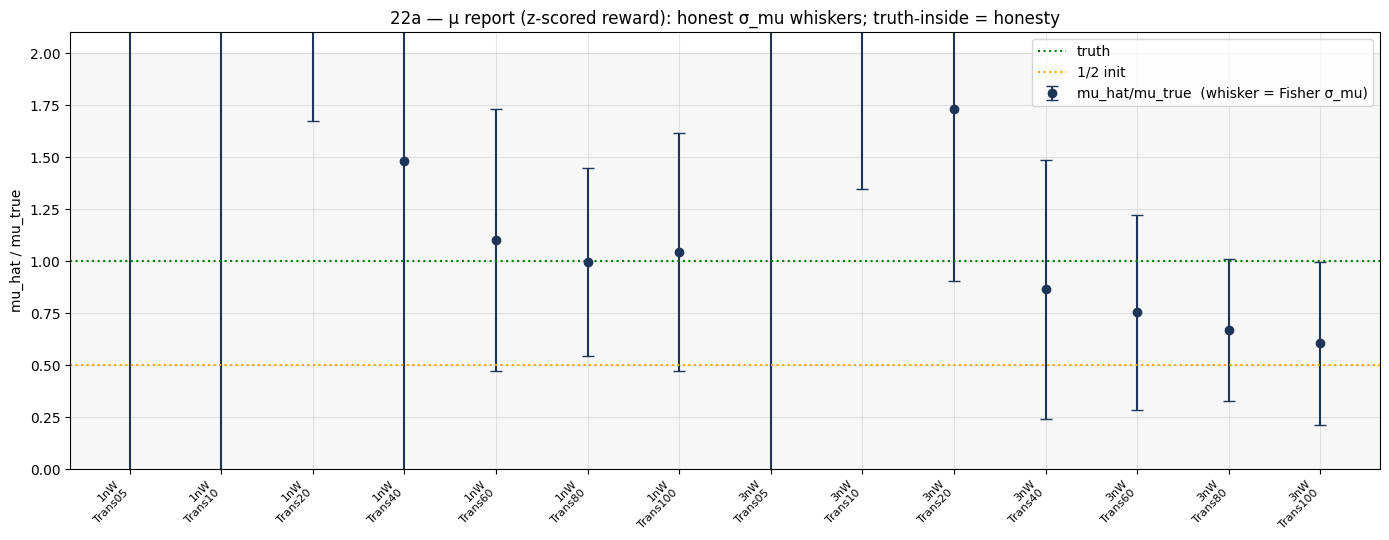

In [11]:
# ============================================================
# FIG 2 — μ report: mu_hat/mu_true with honest Fisher sigma_mu whiskers (per experiment)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5.5))
ys   = [r['mu_final']/r['mu_true'] for r in results]
errs = [r['std_mu']/r['mu_true'] for r in results]
ax.errorbar(np.arange(len(results)), ys, yerr=errs, fmt='o', color='#1d3557', capsize=4, ms=6,
            label='mu_hat/mu_true  (whisker = Fisher σ_mu)')
ax.axhline(1.0, color='g', ls=':', label='truth')
ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
ax.set_xticks(np.arange(len(results)))
ax.set_xticklabels([r['exp'].replace('nW ', 'nW\n') for r in results], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('mu_hat / mu_true'); ax.set_ylim(0, 2.1)
ax.set_title('22a — μ report (z-scored reward): honest σ_mu whiskers; truth-inside = honesty')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

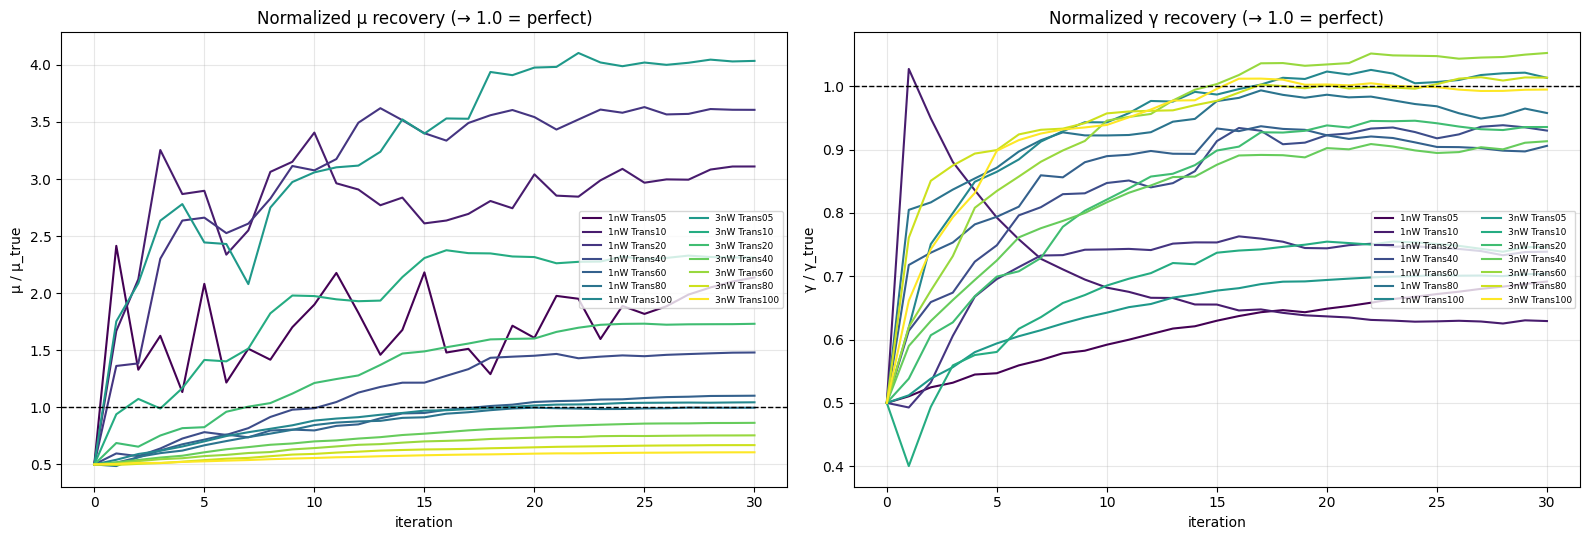

In [12]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
for r, c in zip(results, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()

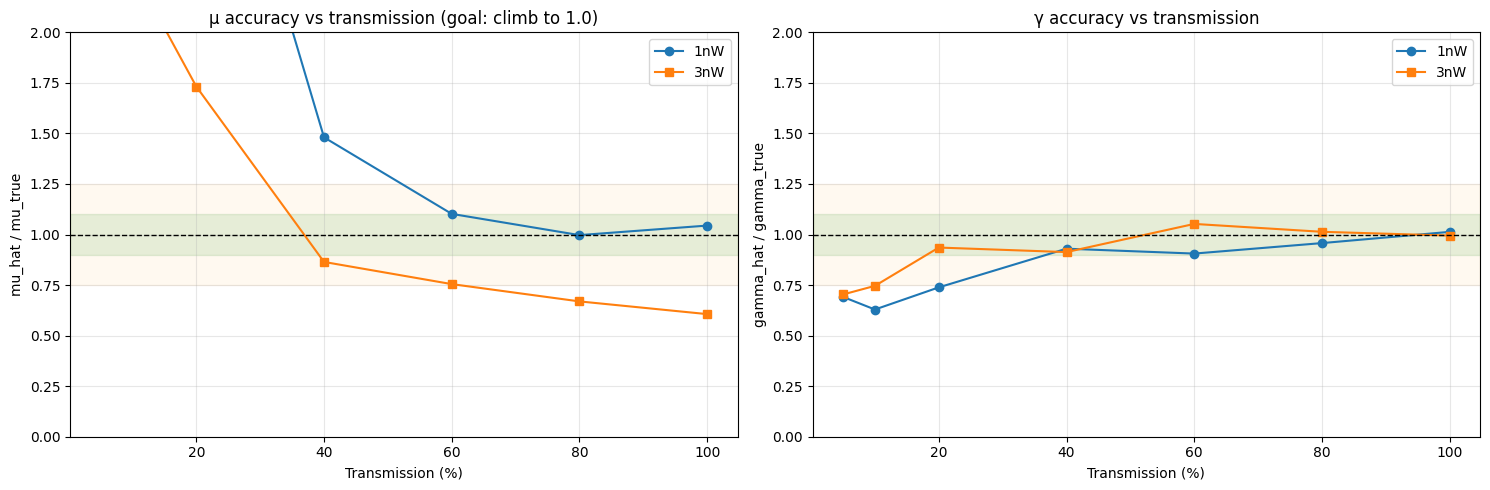

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     2.138     4.035     0.692     0.704
   10      3.11     2.312     0.629     0.746
   20     3.606     1.732     0.739     0.936
   40     1.481     0.864      0.93     0.913
   60     1.102     0.755     0.906     1.052
   80     0.997     0.669     0.958     1.014
  100     1.044     0.606     1.013     0.995


In [13]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in results if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in results}):
    row = [T]
    for p in pows:
        rs = [r for r in results if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in results if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")

## Verdict — the z-scored (adaptive-LR) reward does NOT fix μ; the residual is structural, not reward-scale

Single arm, one change vs 21i: `REWARD_MODE 'loglik_sum' -> 'loglik_z'` (everything else = 21i: no clip, no
clamps, divergence STOP). 14 experiments, 100×30, 14.9 min, **0 divergences**. LR re-matched: median init
`|grad_mu_z| = 1.94` across the 14 experiments → **`LR_MU_Z = 1.70`** (TARGET_STEP 3.3 = 21i's median step).

**(a) Refuted.** μ rel-RMSE **132.5%**, rel-bias **+74.7%** — *worse* than 21i's 40.6% / +7.3%. μ ratios
0.61–4.03 vs 21i's 0.51–1.98. Making the step adaptive (`LR ∝ 1/std(r)`) did not move the μ landing toward
truth; it moved it away.

**(b) Where it changed.**
- **1nW high-T improved:** T60/T80/T100 = 1.10 / 1.00 / 1.04 (21i: 0.94 / 0.86 / 0.87) — now essentially at truth.
- **Low/mid-T overshoot got much worse:** 1nW T05/T10/T20 = 2.14 / 3.11 / 3.61 and 3nW T05/T10/T20 =
  4.03 / 2.31 / 1.73 (21i overshot only modestly, ≤ ~2).
- **3nW high-T undershoot unchanged:** T40/T60/T80/T100 = 0.86 / 0.75 / 0.67 / 0.61 (21i: 0.95 / 0.74 / 0.66 / 0.62).

**(c) The normalisation worked; μ still didn't improve.** z-scoring compressed the init `|grad_mu|` spread
from ~400× (21i) to ~43× (min 0.25 / median 1.94 / max 10.6) — exactly its purpose — yet μ got worse. So the
μ residual is **not** a reward-scale problem: equalising the step hurts the low-T cells more than it helps
the high-T ones.

**(d) γ is not the lever (and got slightly better).** γ rel-RMSE **18.6%** (21i ~21% over its 13 finite
cells) and **0 divergences** — the 1nW T05 γ blow-up that 21i hit does not occur here, because the changed μ
trajectory shifts the states at which γ's (pathwise) gradient is evaluated. γ stays a secondary channel.

**(e) μ remains honest-but-uninformative.** Fisher σ_mu is large (e.g. 1845 at 1nW T05; 23–113 elsewhere),
so the whiskers dwarf the bias — consistent with the 21-series information-limit reading (σ_μ/μ_true large;
the data does not pin a sharp μ).

**Series conclusion.** Together with 21e (reward swaps), 21g–h (score denominator), 21i (clip) and 21k
(sampling), the z-score test closes the loop: **no reward-side manipulation moves the μ landing.** The μ bias
is structural (simulator model gap E10 / information limit) — not a reward normalisation, scale, clip or
sample-count problem. The real value of 22a is the machinery: the interactive (μ,γ)-path + generated-
distribution viewer that the rest of series 22 builds on.